In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

### Load Trained Weights for Model with 7 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [32]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [33]:
len(model_7.bert.encoder.layer)

7

In [34]:
model_7.to(device)
device

device(type='cuda', index=1)

In [35]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.8700980392156863, 'f1': 0.9084628670120898}

# 5. Pruning Study

In [37]:
analysis_save_path = './save_analysis'

### Masking 10 percent of amount

In [38]:
num_att_mask = int(12 * 12 * 0.1)
num_att_mask

14

In [39]:
num_int_mask = int(model.bert.encoder.layer[0].intermediate.dense.weight.shape[0] * 12 * 0.1)
num_int_mask

3686

## 5.1 Attention Heads

### 12 Layers

In [40]:
from structure_prune_helper import register_importance_masks, remove_importance_masks, iterativeMask, plot_masking_results

In [83]:
register_importance_masks(model, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (12 heads)
  Layer 8: Registered masks (12 heads)
  Layer 9: Registered masks (12 heads)
  Layer 10: Registered masks (12 heads)
  Layer 11: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [84]:
mask_history_head = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:09<00:00, 10.49it/s]


Masking 14 / 144 heads (9.7%)
  Masked layer 11, head 1 (importance: 0.000000)
  Masked layer 11, head 3 (importance: 0.000000)
  Masked layer 11, head 0 (importance: 0.000000)
  Masked layer 11, head 6 (importance: 0.000000)
  Masked layer 11, head 11 (importance: 0.000000)
  ... and 9 more
Remaining Heads: 130, Total Heads: 144


TypeError: 'int' object is not callable

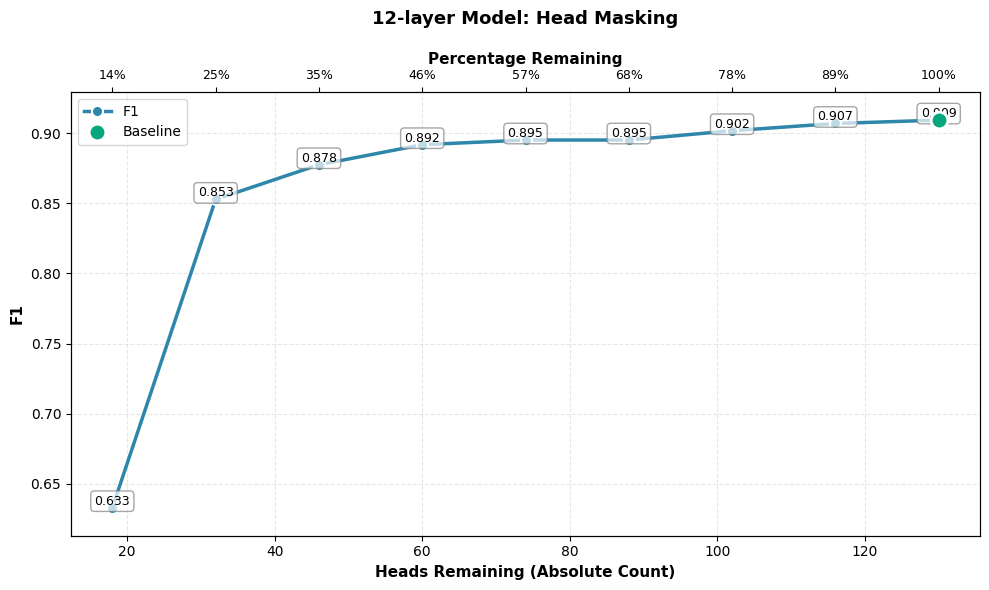

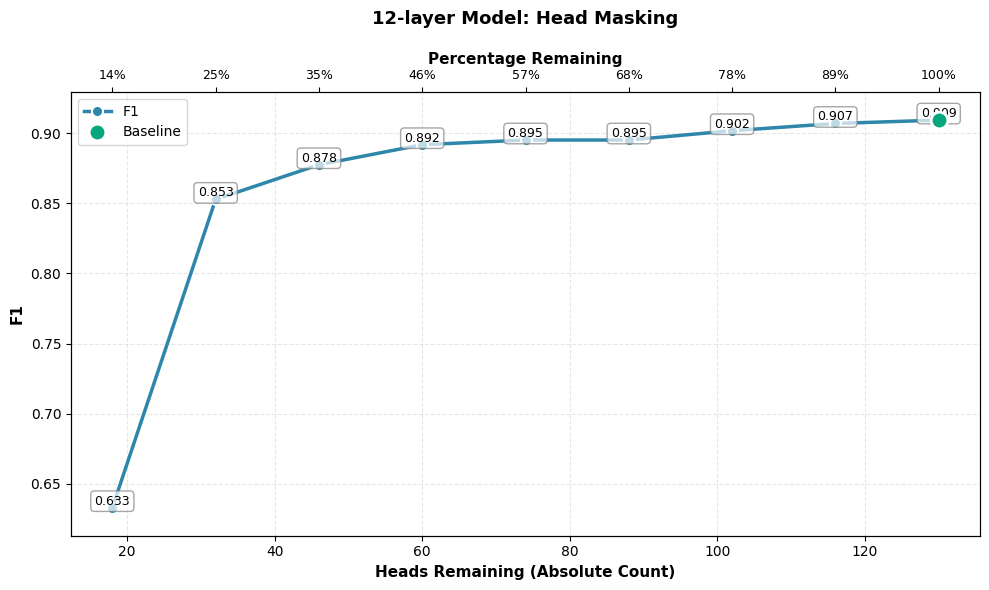

In [43]:
plot_masking_results(mask_history_head, metric='f1', component='heads', title='12-layer Model: Head Masking')

In [44]:
remove_importance_masks(model, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [45]:
torch.save(mask_history_head, f'{analysis_save_path}/{task_name}')

In [41]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [42]:
mask_history_head = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=2
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:11<00:00,  9.04it/s]



Masking 14 / 144 heads (9.7%)
  Masked layer 11, head 1 (importance: 0.000000)
  Masked layer 11, head 3 (importance: 0.000000)
  Masked layer 11, head 0 (importance: 0.000000)
  Masked layer 11, head 6 (importance: 0.000000)
  Masked layer 11, head 11 (importance: 0.000000)
  ... and 9 more
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 12 (100.0%)
Layer: 7, total: 12, Remain: 10 (83.33%)
Layer: 8, total: 12, Remain: 12 (100.0%)
Layer: 9, total: 12, Remain: 11 (91.67%)
Layer: 10, total: 12, Remain: 7 (58.33%)
Layer: 11, total: 12, Remain: 6 (50.0%)
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:10<00:00,  9.99it/s]



Masking 14 / 144 heads (9.7%)
  Masked layer 8, head 6 (importance: 0.000000)
  Masked layer 10, head 3 (importance: 0.000000)
  Masked layer 9, head 1 (importance: 0.000000)
  Masked layer 9, head 3 (importance: 0.000000)
  Masked layer 9, head 6 (importance: 0.000001)
  ... and 9 more
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 12, Remain: 9 (75.0%)
Layer: 8, total: 12, Remain: 8 (66.67%)
Layer: 9, total: 12, Remain: 7 (58.33%)
Layer: 10, total: 12, Remain: 5 (41.67%)
Layer: 11, total: 12, Remain: 4 (33.33%)
  Metrics:
      accuracy: 0.8627
    ★ f1: 0.9070


In [43]:
mask_history_head

{'head_mask_remaining': [130, 116],
 'head_mask_state': [[[1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0],
   [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0],
   [0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0]],
  [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1

In [42]:
mask_history_int = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=1
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:11<00:00,  8.92it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 0, neuron 2165 (importance: 0.000000)
  Masked layer 11, neuron 861 (importance: 0.000000)
  Masked layer 11, neuron 2256 (importance: 0.000000)
  Masked layer 0, neuron 2172 (importance: 0.000000)
  Masked layer 11, neuron 1460 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 3072, Remain: 3071 (99.97%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3071 (99.97%)
Layer: 4, total: 3072, Remain: 3071 (99.97%)
Layer: 5, total: 3072, Remain: 3067 (99.84%)
Layer: 6, total: 3072, Remain: 3068 (99.87%)
Layer: 7, total: 3072, Remain: 3071 (99.97%)
Layer: 8, total: 3072, Remain: 3053 (99.38%)
Layer: 9, total: 3072, Remain: 2648 (86.2%)
Layer: 10, total: 3072, Remain: 1979 (64.42%)
Layer: 11, total: 3072, Remain: 938 (30.53%)
  Metrics:
      accuracy: 0.8652
    ★ f1: 0.90

In [44]:
def remaining_layers_stat(model, component='head'):
    stats = []
    for idx, layer in enumerate(model.bert.encoder.layer):
        if component == 'head':
            out_list = layer.head_mask_param.detach().cpu().tolist()
        else:
            out_list = layer.int_mask_param.detach().cpu().tolist()

        obj = {
            'layer': idx,
            'n_remain': int(sum(out_list)),
            'total': len(out_list)
        }
        stats.append(obj)

    return stats

In [45]:
remain_stats = remaining_layers_stat(model, component='head')
remain_stats 

[{'layer': 0, 'n_remain': 12, 'total': 12},
 {'layer': 1, 'n_remain': 12, 'total': 12},
 {'layer': 2, 'n_remain': 12, 'total': 12},
 {'layer': 3, 'n_remain': 12, 'total': 12},
 {'layer': 4, 'n_remain': 12, 'total': 12},
 {'layer': 5, 'n_remain': 12, 'total': 12},
 {'layer': 6, 'n_remain': 12, 'total': 12},
 {'layer': 7, 'n_remain': 10, 'total': 12},
 {'layer': 8, 'n_remain': 12, 'total': 12},
 {'layer': 9, 'n_remain': 11, 'total': 12},
 {'layer': 10, 'n_remain': 7, 'total': 12},
 {'layer': 11, 'n_remain': 6, 'total': 12}]

In [48]:
for stat in remain_stats:
    remain = stat['n_remain'] * 100/ stat['total']
    remain = round(remain, 2)
    print(f"Layer: {stat['layer']}, total: {stat['total']}, Remain: {stat['n_remain']} ({remain}%)")

# remaining_layers_stat(model, component='ffn')

Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 12 (100.0%)
Layer: 7, total: 12, Remain: 10 (83.33%)
Layer: 8, total: 12, Remain: 12 (100.0%)
Layer: 9, total: 12, Remain: 11 (91.67%)
Layer: 10, total: 12, Remain: 7 (58.33%)
Layer: 11, total: 12, Remain: 6 (50.0%)


In [56]:
model.bert.encoder.layer[0].head_mask_param.detach().cpu().tolist()

for idx, layer in enumerate(model.bert.encoder.layer):
    out_list = layer.head_mask_param.detach().cpu().tolist()
    num_remaining = int(sum(out_list))
    total = len(out_list)
    print(idx)
    print(f'{num_remaining} of {total}')

0
12 of 12
1
12 of 12
2
12 of 12
3
12 of 12
4
12 of 12
5
12 of 12
6
12 of 12
7
12 of 12
8
12 of 12
9
12 of 12
10
12 of 12
11
12 of 12


### 7 Layers

In [45]:
register_importance_masks(model_7, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (24 heads)
  Layer 6: Registered masks (48 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [46]:
mask_history_head_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:12<00:00,  8.13it/s]



Masking 14 / 144 heads (9.7%)
  Masked layer 6, head 13 (importance: 0.000000)
  Masked layer 6, head 15 (importance: 0.000000)
  Masked layer 6, head 11 (importance: 0.000000)
  Masked layer 6, head 28 (importance: 0.000000)
  Masked layer 6, head 37 (importance: 0.000000)
  ... and 9 more
Remaining Heads: 130
  Metrics:
      accuracy: 0.8652
    ★ f1: 0.9060

Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:12<00:00,  8.20it/s]



Masking 14 / 144 heads (9.7%)
  Masked layer 1, head 3 (importance: 0.000000)
  Masked layer 5, head 11 (importance: 0.000000)
  Masked layer 6, head 32 (importance: 0.000000)
  Masked layer 5, head 19 (importance: 0.000000)
  Masked layer 0, head 7 (importance: 0.000000)
  ... and 9 more
Remaining Heads: 116
  Metrics:
      accuracy: 0.8627
    ★ f1: 0.9051

Round: 2


...


Masking 14 / 144 heads (9.7%)
  Masked layer 1, head 22 (importance: 0.000003)
  Masked layer 0, head 11 (importance: 0.000003)
  Masked layer 1, head 21 (importance: 0.000004)
  Masked layer 1, head 0 (importance: 0.000004)
  Masked layer 1, head 2 (importance: 0.000004)
  ... and 9 more
Remaining Heads: 46
  Metrics:
      accuracy: 0.7892
    ★ f1: 0.8613

Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:11<00:00,  8.54it/s]



Masking 14 / 144 heads (9.7%)
  Masked layer 4, head 5 (importance: 0.000013)
  Masked layer 5, head 4 (importance: 0.000013)
  Masked layer 2, head 3 (importance: 0.000014)
  Masked layer 2, head 9 (importance: 0.000016)
  Masked layer 0, head 10 (importance: 0.000016)
  ... and 9 more
Remaining Heads: 32
  Metrics:
      accuracy: 0.6520
    ★ f1: 0.6966

Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:12<00:00,  7.95it/s]



Masking 14 / 144 heads (9.7%)
  Masked layer 5, head 22 (importance: 0.000011)
  Masked layer 0, head 1 (importance: 0.000017)
  Masked layer 0, head 8 (importance: 0.000020)
  Masked layer 1, head 10 (importance: 0.000020)
  Masked layer 1, head 11 (importance: 0.000029)
  ... and 9 more
Remaining Heads: 18
  Metrics:
      accuracy: 0.4559
    ★ f1: 0.3934


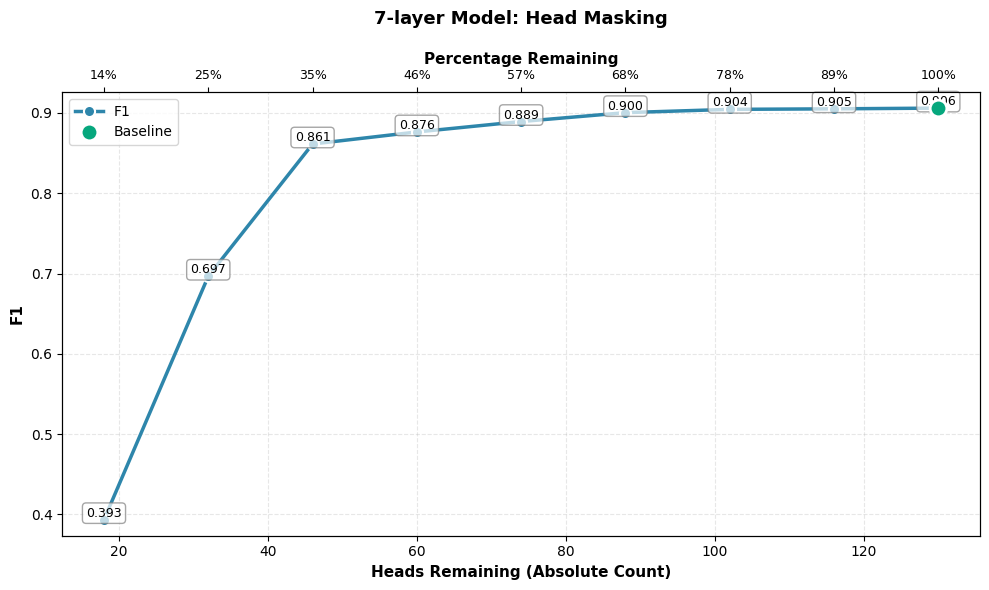

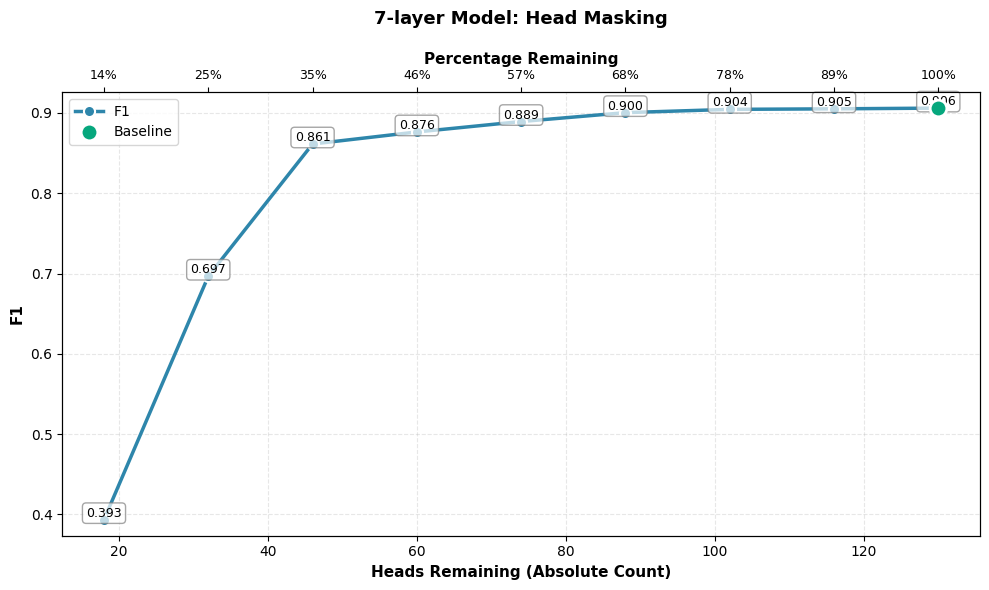

In [47]:
plot_masking_results(mask_history_7, metric='f1', component='heads', title='7-layer Merged: Head Masking')

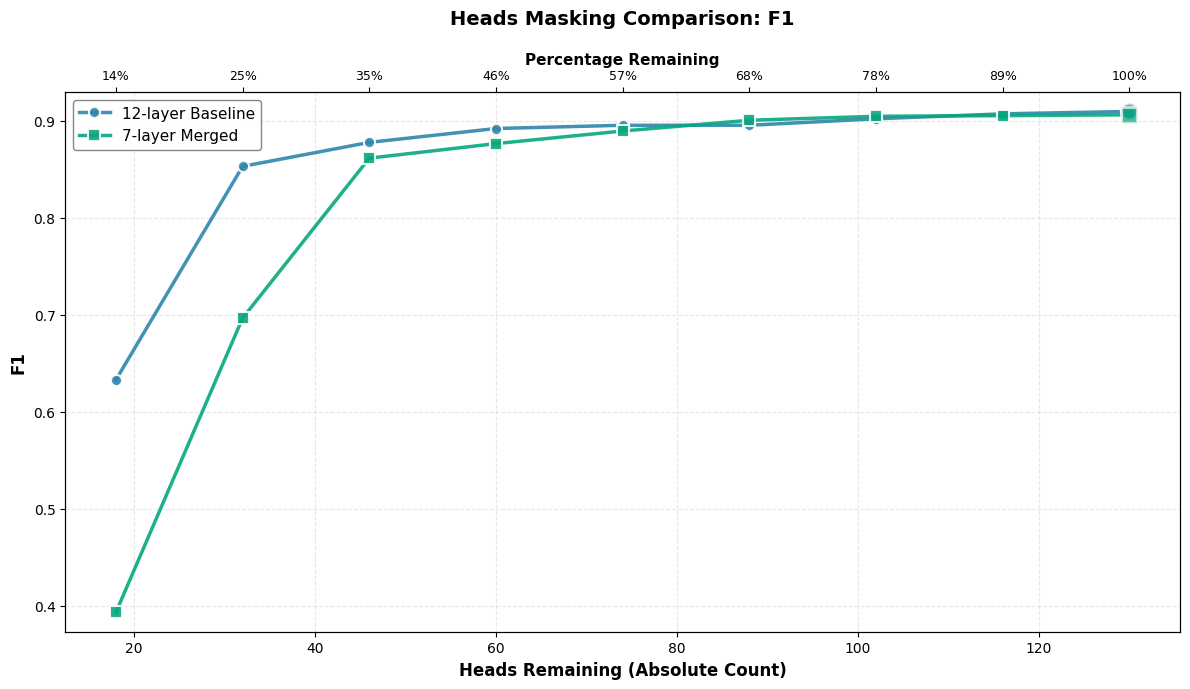

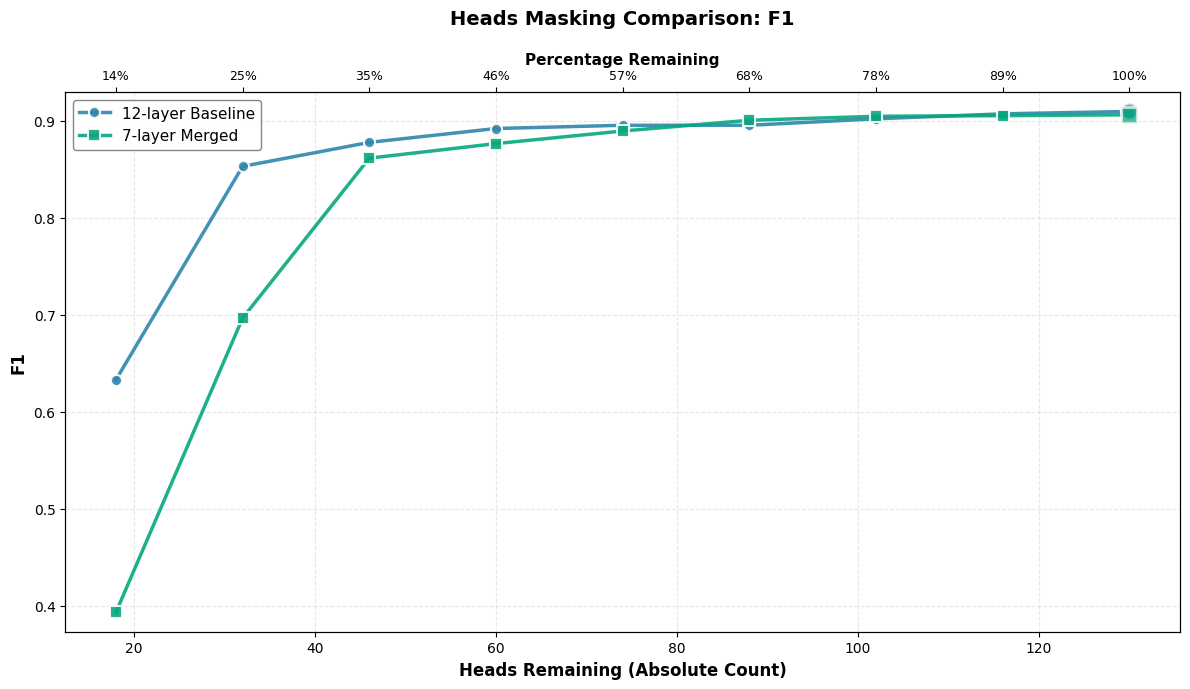

In [52]:
plot_masking_comparison([mask_history, mask_history_7], labels=['12-layer Baseline', '7-layer Merged'], metric='f1', component='heads')

In [53]:
remove_importance_masks(model, remove_heads=True, remove_ffn=False)

✓ Removed head masks


## 5.2 FFN Neurons

### 12 Layers

In [55]:
register_importance_masks(model, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (3072 neurons)
  Layer 8: Registered masks (3072 neurons)
  Layer 9: Registered masks (3072 neurons)
  Layer 10: Registered masks (3072 neurons)
  Layer 11: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [56]:
mask_history = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:11<00:00,  8.40it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 0, neuron 2165 (importance: 0.000000)
  Masked layer 11, neuron 861 (importance: 0.000000)
  Masked layer 11, neuron 2256 (importance: 0.000000)
  Masked layer 11, neuron 605 (importance: 0.000000)
  Masked layer 0, neuron 2172 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 33178
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9109

Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:12<00:00,  8.18it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 10, neuron 2205 (importance: 0.000000)
  Masked layer 10, neuron 247 (importance: 0.000000)
  Masked layer 10, neuron 853 (importance: 0.000000)
  Masked layer 10, neuron 2371 (importance: 0.000000)
  Masked layer 11, neuron 207 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 29492
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
  Masked layer 5, neuron 1108 (importance: 0.000000)
  Masked layer 7, neuron 906 (importance: 0.000000)
  Masked layer 9, neuron 1978 (importance: 0.000000)
  Masked layer 10, neuron 1713 (importance: 0.000000)
  Masked layer 6, neuron 1760 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 11062
  Metrics:
      accuracy: 0.8284
    ★ f1: 0.8837

Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:14<00:00,  6.90it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 8, neuron 1320 (importance: 0.000000)
  Masked layer 6, neuron 1917 (importance: 0.000000)
  Masked layer 7, neuron 95 (importance: 0.000000)
  Masked layer 7, neuron 1093 (importance: 0.000000)
  Masked layer 8, neuron 3030 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 7376
  Metrics:
      accuracy: 0.7843
    ★ f1: 0.8301

Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:12<00:00,  8.09it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 6, neuron 1854 (importance: 0.000000)
  Masked layer 4, neuron 841 (importance: 0.000000)
  Masked layer 4, neuron 2810 (importance: 0.000000)
  Masked layer 3, neuron 537 (importance: 0.000000)
  Masked layer 4, neuron 2560 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 3690
  Metrics:
      accuracy: 0.7353
    ★ f1: 0.7891


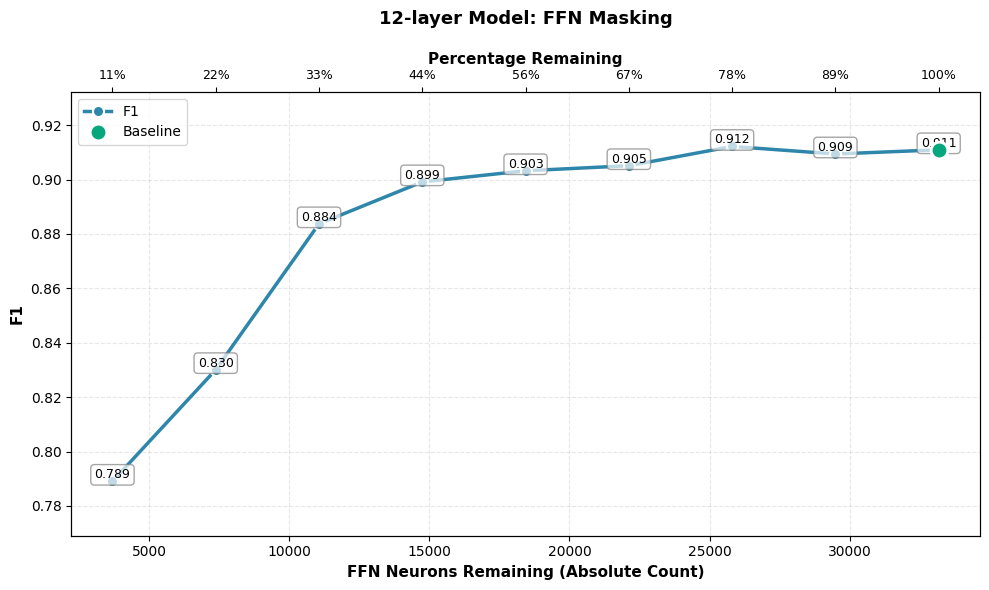

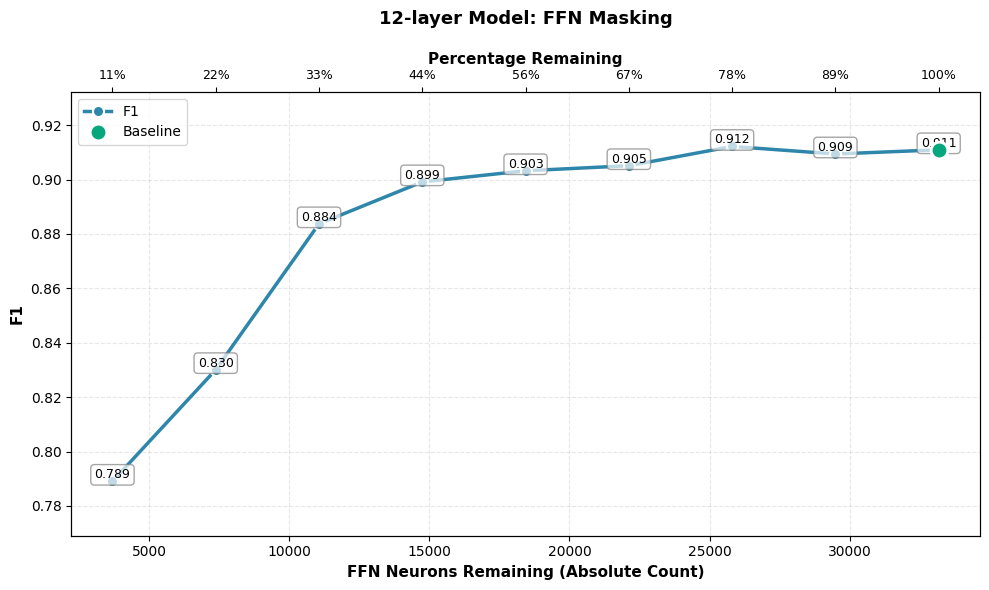

In [57]:
plot_masking_results(mask_history, metric='f1', component='ffn', title='12-layer Model: FFN Masking')

In [58]:
remove_importance_masks(model, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


### 7 Layers

In [65]:
register_importance_masks(model_7, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (6144 neurons)
  Layer 6: Registered masks (12288 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [ ]:
mask_history_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:12<00:00,  7.91it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 6, neuron 5256 (importance: 0.000000)
  Masked layer 0, neuron 2165 (importance: 0.000000)
  Masked layer 6, neuron 6030 (importance: 0.000000)
  Masked layer 6, neuron 5261 (importance: 0.000000)
  Masked layer 1, neuron 2065 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 33178
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:11<00:00,  8.50it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 0, neuron 2172 (importance: 0.000000)
  Masked layer 5, neuron 995 (importance: 0.000000)
  Masked layer 6, neuron 1985 (importance: 0.000000)
  Masked layer 6, neuron 11890 (importance: 0.000000)
  Masked layer 6, neuron 11068 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 29492
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9069

Round: 2


...

Computing importance (FFN only): 100%|██████████| 100/100 [00:12<00:00,  7.86it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 6, neuron 2545 (importance: 0.000000)
  Masked layer 5, neuron 412 (importance: 0.000000)
  Masked layer 5, neuron 3405 (importance: 0.000000)
  Masked layer 6, neuron 8861 (importance: 0.000000)
  Masked layer 4, neuron 594 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 11062
  Metrics:
      accuracy: 0.8382
    ★ f1: 0.8858

Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:10<00:00,  9.28it/s]



Masking 3686 / 36864 neurons (10.0%)
  Masked layer 3, neuron 1562 (importance: 0.000000)
  Masked layer 6, neuron 2518 (importance: 0.000000)
  Masked layer 2, neuron 527 (importance: 0.000000)
  Masked layer 4, neuron 1230 (importance: 0.000000)
  Masked layer 6, neuron 2366 (importance: 0.000000)
  ... and 3681 more
Remaining FFN Neurons: 7376
  Metrics:
      accuracy: 0.8235
    ★ f1: 0.8714

Round: 8


Computing importance (FFN only):  31%|███       | 31/100 [00:03<00:06,  9.99it/s]

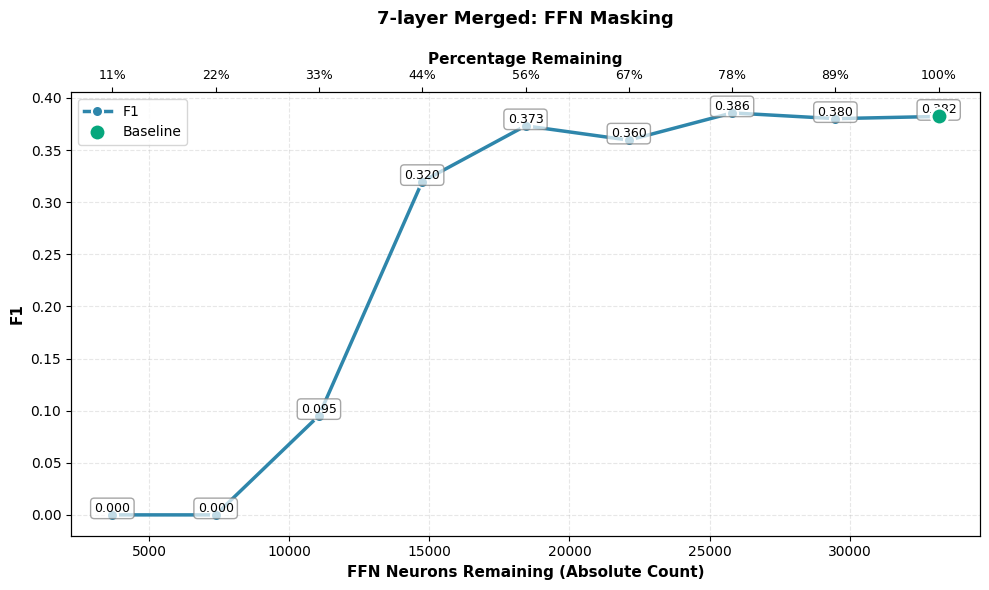

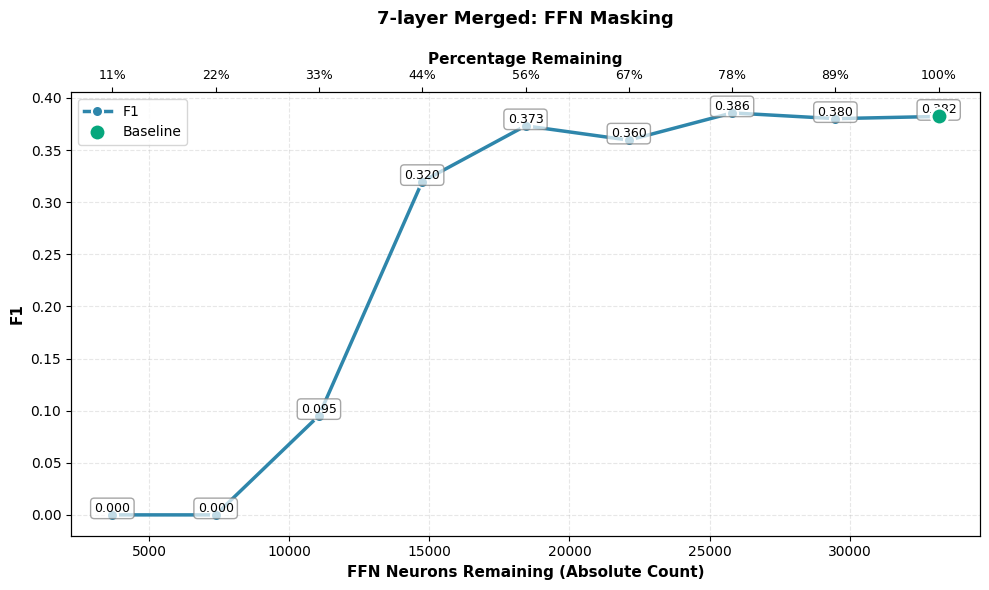

In [62]:
plot_masking_results(mask_history_7, metric='f1', component='ffn', title='7-layer Merged: FFN Masking')

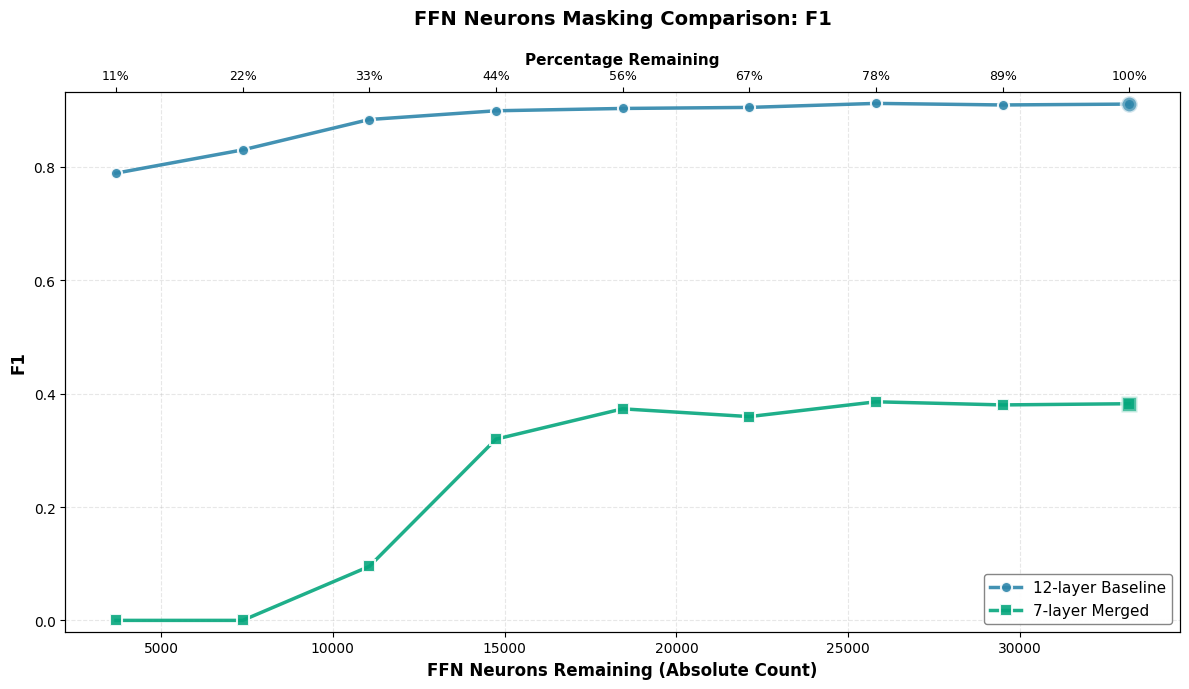

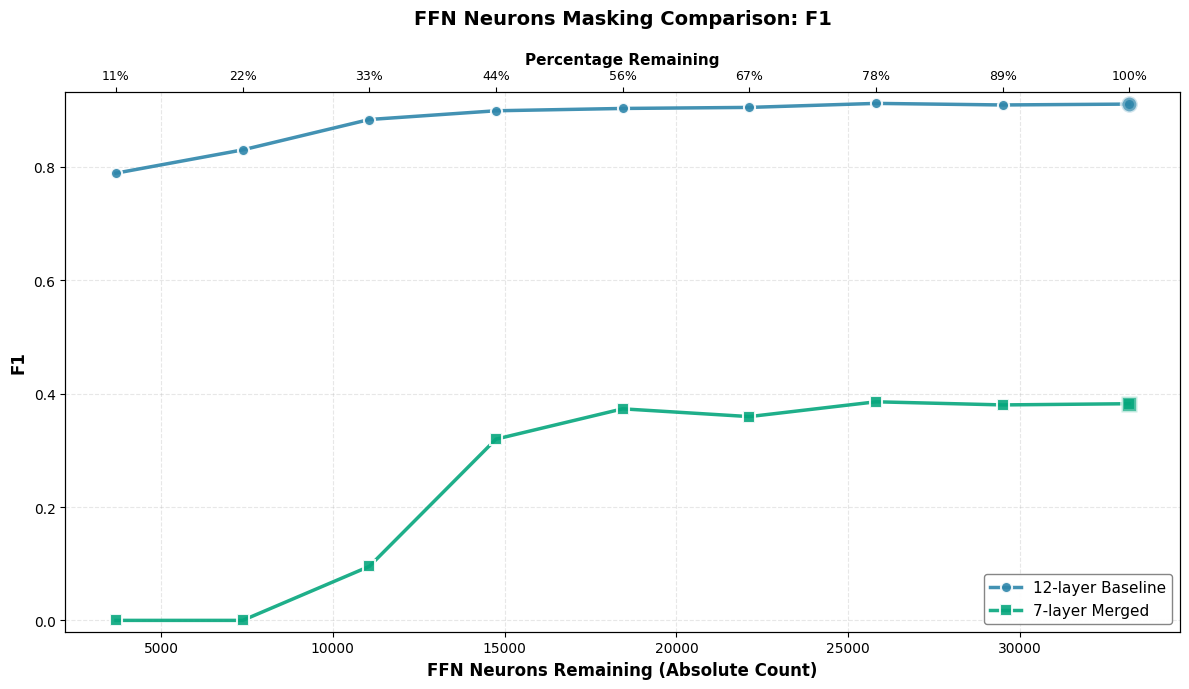

In [63]:
plot_masking_comparison([mask_history, mask_history_7], labels=['12-layer Baseline', '7-layer Merged'], metric='f1', component='ffn')